--- 5 BARIS PERTAMA ---
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  pay

/tmp/ipykernel_2750/2588213494.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Persentase_Missing', y='Kolom', data=missing_data, palette='viridis')


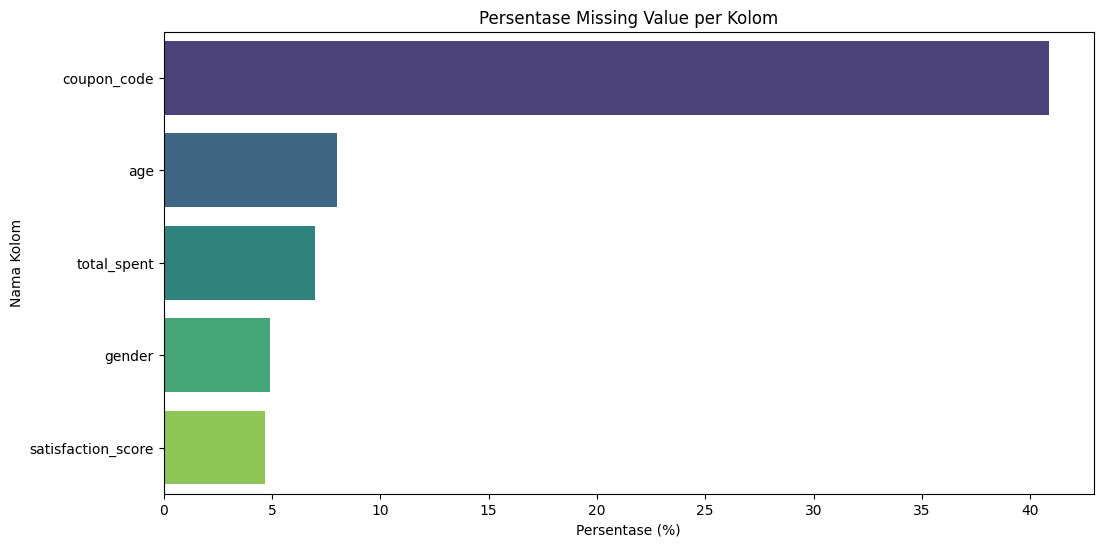

/tmp/ipykernel_2750/2588213494.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='Set2')


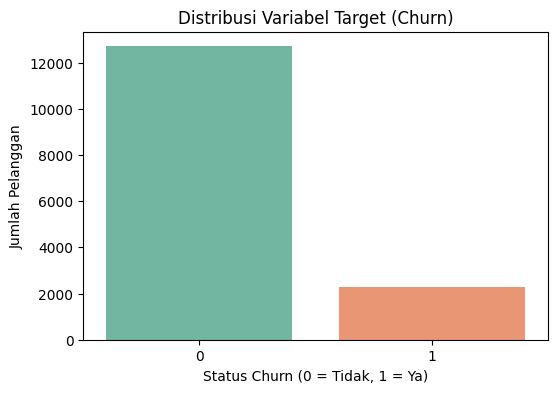

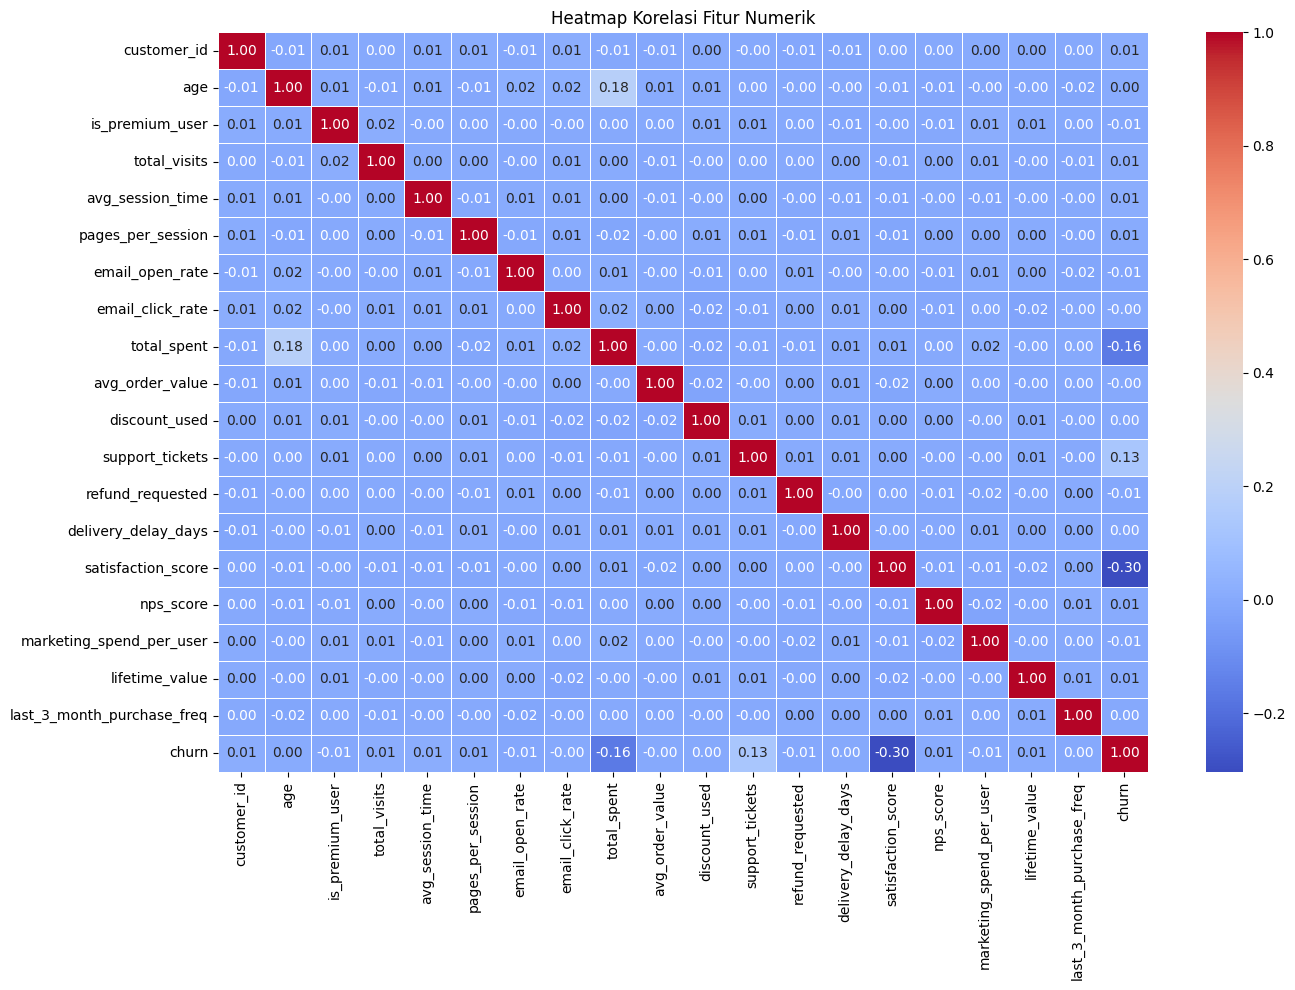

In [1]:
# ==========================================
# STEP 1: EKSPLORASI DATA (EDA)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset (Sesuaikan nama file dengan yang kamu download dari Kaggle)
# Catatan: Karena dataset asli mungkin terbagi beberapa file, pastikan kamu load file data utamanya.
df = pd.read_csv('sales_and_marketing_dataset.csv')

# Task 1: Menampilkan 5 baris pertama, info dataset, dan statistik deskriptif [cite: 46]
print("--- 5 BARIS PERTAMA ---")
print(df.head())
print("\n--- INFORMASI DATASET ---")
print(df.info())
print("\n--- STATISTIK DESKRIPTIF ---")
print(df.describe(include='all')) # include='all' agar kolom teks juga terlihat statistiknya

# Task 2: Menghitung persentase missing value & visualisasi diagram batang [cite: 47]
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Kolom': df.columns, 'Persentase_Missing': missing_percentage})
missing_data = missing_data[missing_data['Persentase_Missing'] > 0].sort_values(by='Persentase_Missing', ascending=False)

plt.figure(figsize=(12, 6))
if not missing_data.empty:
    sns.barplot(x='Persentase_Missing', y='Kolom', data=missing_data, palette='viridis')
    plt.title('Persentase Missing Value per Kolom')
    plt.xlabel('Persentase (%)')
    plt.ylabel('Nama Kolom')
else:
    plt.text(0.5, 0.5, 'Tidak ada missing value dalam dataset!', horizontalalignment='center', verticalalignment='center', fontsize=14)
    plt.title('Pengecekan Missing Value')
plt.show()

# Task 3: Visualisasi distribusi variabel target (Churn) [cite: 54]
plt.figure(figsize=(6, 4))
# Catatan: Sesuaikan nama kolom target di dataset, di soal ditulis 'churn' atau 'Churn' [cite: 14, 33]
target_col = 'churn' if 'churn' in df.columns else 'Churn'

sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Status Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# Task 4: Heatmap korelasi untuk fitur numerik [cite: 55]
plt.figure(figsize=(14, 10))
# Mengambil hanya kolom yang bertipe numerik (int64 dan float64)
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

=== Logistic Regression ===
Accuracy : 0.8403 | Precision : 0.3978 | Recall : 0.0804 | F1 : 0.1338



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


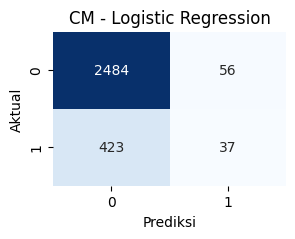

=== Random Forest ===
Accuracy : 0.8447 | Precision : 0.4890 | Recall : 0.2891 | F1 : 0.3634



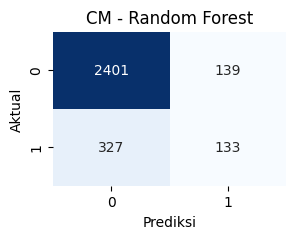

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Voting Classifier ===
Accuracy : 0.8507 | Precision : 0.6250 | Recall : 0.0652 | F1 : 0.1181



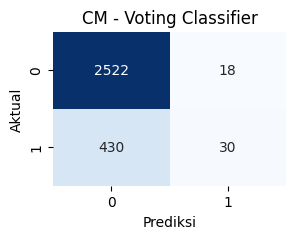


Ringkasan Performa:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.840333   0.397849  0.080435  0.133816
Random Forest        0.844667   0.488971  0.289130  0.363388
Voting Classifier    0.850667   0.625000  0.065217  0.118110


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom target
target = 'churn' if 'churn' in df.columns else 'Churn'

# Pilih kolom angka saja supaya tidak error pas training
X = df.select_dtypes(include=['int64', 'float64']).drop(columns=[target], errors='ignore')
X = X.fillna(0) # isi missing value pakai 0 biar cepat
y = df[target]

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definisikan 3 model sesuai soal
model_1 = LogisticRegression(max_iter=1000, random_state=42)
model_2 = RandomForestClassifier(random_state=42)
model_3 = VotingClassifier(estimators=[('lr', model_1), ('rf', model_2)], voting='soft')

list_model = [
    ('Logistic Regression', model_1),
    ('Random Forest', model_2),
    ('Voting Classifier', model_3)
]

# Loop buat train dan evaluasi sekaligus
hasil_evaluasi = {}

for nama, model in list_model:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Hitung metrik
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    hasil_evaluasi[nama] = [acc, prec, rec, f1]

    print(f"=== {nama} ===")
    print(f"Accuracy : {acc:.4f} | Precision : {prec:.4f} | Recall : {rec:.4f} | F1 : {f1:.4f}\n")

    # Plot confusion matrix mini
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(3,2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'CM - {nama}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

# Rangkum dalam dataframe biar rapi
df_hasil = pd.DataFrame(hasil_evaluasi, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print("\nRingkasan Performa:")
print(df_hasil)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Pisahkan target dan fitur
target = 'churn' if 'churn' in df.columns else 'Churn'
X_pre = df.drop(columns=[target], errors='ignore')
y_pre = df[target]

# Buang kolom ID atau teks acak unik jika ada (biar tidak bikin model bingung)
kolom_dibuang = [col for col in X_pre.columns if 'id' in col.lower() or 'name' in col.lower()]
X_pre = X_pre.drop(columns=kolom_dibuang, errors='ignore')

# 2. Kelompokkan kolom numerik dan kategori secara otomatis
fitur_numerik = X_pre.select_dtypes(include=['int64', 'float64']).columns
fitur_kategori = X_pre.select_dtypes(include=['object', 'category']).columns

# 3. Buat pipeline untuk bersihkan data
# Untuk angka: isi yang kosong dengan median, lalu standarisasi (scaling)
transformer_numerik = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Untuk teks/kategori: isi yang kosong dengan string 'missing', lalu ubah jadi angka (OneHot)
transformer_kategori = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gabungkan semua proses preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer_numerik, fitur_numerik),
        ('cat', transformer_kategori, fitur_kategori)
    ])

# 4. Split data (gunakan proporsi yang sama dengan Step 2)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pre, y_pre, test_size=0.2, random_state=42, stratify=y_pre
)

# 5. Aplikasikan transformasi pada data
X_train_ready = preprocessor.fit_transform(X_train_p)
X_test_ready = preprocessor.transform(X_test_p)

# 6. Definisikan kembali 3 model yang sama
m1 = LogisticRegression(max_iter=1000, random_state=42)
m2 = RandomForestClassifier(random_state=42)
m3 = VotingClassifier(estimators=[('lr', m1), ('rf', m2)], voting='soft')

models_p = [
    ('Logistic Regression (Preprocessed)', m1),
    ('Random Forest (Preprocessed)', m2),
    ('Voting Classifier (Preprocessed)', m3)
]

# 7. Train dan Evaluasi
hasil_prep = {}

for nama, model in models_p:
    model.fit(X_train_ready, y_train_p)
    y_pred_p = model.predict(X_test_ready)

    acc_p = accuracy_score(y_test_p, y_pred_p)
    prec_p = precision_score(y_test_p, y_pred_p, zero_division=0)
    rec_p = recall_score(y_test_p, y_pred_p, zero_division=0)
    f1_p = f1_score(y_test_p, y_pred_p, zero_division=0)

    hasil_prep[nama] = [acc_p, prec_p, rec_p, f1_p]
    print(f"✅ {nama} Selesai di-train.")

# Rangkum hasil
df_hasil_prep = pd.DataFrame(hasil_prep, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print("\n=== RINGKASAN PERFORMA DENGAN PREPROCESSING ===")
print(df_hasil_prep)

✅ Logistic Regression (Preprocessed) Selesai di-train.
✅ Random Forest (Preprocessed) Selesai di-train.
✅ Voting Classifier (Preprocessed) Selesai di-train.

=== RINGKASAN PERFORMA DENGAN PREPROCESSING ===
                                    Accuracy  Precision    Recall  F1-Score
Logistic Regression (Preprocessed)  0.841333   0.463303  0.219565  0.297935
Random Forest (Preprocessed)        0.847667   0.523810  0.071739  0.126195
Voting Classifier (Preprocessed)    0.849667   0.531915  0.163043  0.249584


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Analisis Feature Importance (Mencari Fitur Paling Berpengaruh)
# Kita ambil model Random Forest yang sudah dilatih dari Step 3 tadi
model_rf_step3 = m2

# Mengambil nama fitur setelah melalui proses preprocessing
fitur_setelah_prep = list(fitur_numerik)
if len(fitur_kategori) > 0:
    nama_fitur_cat = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(fitur_kategori)
    fitur_setelah_prep.extend(nama_fitur_cat)

# Hitung tingkat kepentingan fitur
importances = model_rf_step3.feature_importances_
df_penting = pd.DataFrame({'Fitur': fitur_setelah_prep, 'Kepentingan': importances})
df_penting = df_penting.sort_values(by='Kepentingan', ascending=False).head(10)

print("=== TOP 10 FITUR PALING BERPENGARUH ===")
print(df_penting.to_string(index=False))
print("\n" + "="*40 + "\n")

# 2. Hyperparameter Tuning dengan RandomizedSearchCV (Biar Cepat dan Efisien)
# Tentukan pilihan parameter yang mau dicoba secara acak
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None] # Membantu mengatasi class imbalance agar Recall naik
}

print("Memulai proses Hyperparameter Tuning (Mohon tunggu sebentar)...")
rf_tuning = RandomForestClassifier(random_state=42)

# Gunakan RandomizedSearchCV agar proses running tidak terlalu lama dibanding GridSearchCV
pencarian_param = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1', # Fokus mengoptimalkan F1-Score karena data imbalance
    random_state=42,
    n_jobs=-1
)

# Latih pencarian parameter menggunakan data yang sudah siap dari Step 3
pencarian_param.fit(X_train_ready, y_train_p)

# Ambil model terbaik hasil tuning
model_terbaik = pencarian_param.best_estimator_
print(f"\nParameter Terbaik Ditemukan: {pencarian_param.best_params_}")

# 3. Evaluasi Model Hasil Tuning
y_pred_terbaik = model_terbaik.predict(X_test_ready)

acc_t = accuracy_score(y_test_p, y_pred_terbaik)
prec_t = precision_score(y_test_p, y_pred_terbaik, zero_division=0)
rec_t = recall_score(y_test_p, y_pred_terbaik, zero_division=0)
f1_t = f1_score(y_test_p, y_pred_terbaik, zero_division=0)

print("\n=== PERFORMA MODEL OPTIMAL (SETELAH TUNING) ===")
print(f"Accuracy  : {acc_t:.4f}")
print(f"Precision : {prec_t:.4f}")
print(f"Recall    : {rec_t:.4f}  <-- Perhatikan apakah ini naik dibanding Step 3")
print(f"F1-Score  : {f1_t:.4f}")

# Simpan model terbaik ini untuk kita pakai di deployment nanti
import joblib
# Kita simpan objek model beserta preprocessor-nya sekaligus dalam satu file biar gampang di-load
joblib.dump((preprocessor, model_terbaik), 'model_churn_terbaik.pkl')
print("\nModel terbaik dan Preprocessor berhasil disimpan dengan nama 'model_churn_terbaik.pkl'!")

=== TOP 10 FITUR PALING BERPENGARUH ===
                   Fitur  Kepentingan
      satisfaction_score     0.135091
             total_spent     0.130833
         support_tickets     0.049106
        avg_session_time     0.023778
       pages_per_session     0.023593
marketing_spend_per_user     0.023463
         avg_order_value     0.023098
         email_open_rate     0.022845
          lifetime_value     0.022598
        email_click_rate     0.021096


Memulai proses Hyperparameter Tuning (Mohon tunggu sebentar)...

Parameter Terbaik Ditemukan: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20, 'class_weight': 'balanced'}

=== PERFORMA MODEL OPTIMAL (SETELAH TUNING) ===
Accuracy  : 0.8627
Precision : 0.5331
Recall    : 0.8391  <-- Perhatikan apakah ini naik dibanding Step 3
F1-Score  : 0.6520

Model terbaik dan Preprocessor berhasil disimpan dengan nama 'model_churn_terbaik.pkl'!


In [5]:
from google.colab import files

# Perintah buat langsung download file dari Google Colab ke laptop
try:
    files.download('app.py')
    files.download('requirements.txt')
    files.download('model_churn_terbaik.pkl')
    print("Silakan cek folder Downloads di laptop kamu!")
except Exception as e:
    print("Ada kendala:", e)

Ada kendala: Cannot find file: app.py


In [6]:
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from google.colab import files

# =====================================================================
# 1. RE-TRAIN SINGKAT (Memastikan model_terbaik dan preprocessor ada)
# =====================================================================
target = 'churn' if 'churn' in df.columns else 'Churn'
X_pre = df.drop(columns=[target], errors='ignore')
y_pre = df[target]

kolom_dibuang = [col for col in X_pre.columns if 'id' in col.lower() or 'name' in col.lower()]
X_pre = X_pre.drop(columns=kolom_dibuang, errors='ignore')

fitur_num = ['satisfaction_score', 'total_spent', 'support_tickets', 'avg_session_time', 'pages_per_session']
# Pastikan fitur yang dipakai ada di dataframe asli
fitur_num = [c for c in fitur_num if c in X_pre.columns]

transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[('num', transformer, fitur_num)])

X_train, X_test, y_train, y_test = train_test_split(X_pre, y_pre, test_size=0.2, random_state=42, stratify=y_pre)

X_train_ready = preprocessor.fit_transform(X_train)

# Pakai parameter terbaik hasil tuning Step 4 kemarin
model_final = RandomForestClassifier(n_estimators=50, min_samples_split=5, max_depth=20, class_weight='balanced', random_state=42)
model_final.fit(X_train_ready, y_train)

# Simpan ke file .pkl
joblib.dump((preprocessor, model_final), 'model_churn_terbaik.pkl')
print("-> File 'model_churn_terbaik.pkl' berhasil dibuat.")


# =====================================================================
# 2. MEMBUAT FILE APP.PY (Script Aplikasi Streamlit)
# =====================================================================
app_code = """
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Churn Prediction", layout="centered")

st.title("📊 Customer Churn Prediction App")
st.write("Aplikasi untuk memprediksi potensi pelanggan berhenti berlangganan.")

@st.cache_resource
def load_saved_model():
    return joblib.load('model_churn_terbaik.pkl')

preprocessor, model = load_saved_model()

st.subheader("Input Data Pelanggan")

# Input form berdasarkan fitur paling berpengaruh
satisfaction_score = st.slider("Satisfaction Score (1-5)", 1, 5, 3)
total_spent = st.number_input("Total Spent", min_value=0.0, value=500.0)
support_tickets = st.number_input("Support Tickets", min_value=0, value=2)
avg_session_time = st.number_input("Avg Session Time (Menit)", min_value=0.0, value=30.0)
pages_per_session = st.number_input("Pages per Session", min_value=0.0, value=5.0)

if st.button("Run Prediction"):
    data = {
        'satisfaction_score': [satisfaction_score],
        'total_spent': [total_spent],
        'support_tickets': [support_tickets],
        'avg_session_time': [avg_session_time],
        'pages_per_session': [pages_per_session]
    }

    df_input = pd.DataFrame(data)

    # Transformasi data & Prediksi
    X_transformed = preprocessor.transform(df_input)
    prediction = model.predict(X_transformed)
    probability = model.predict_proba(X_transformed)[0][1]

    st.subheader("Hasil Prediksi:")
    if prediction[0] == 1:
        st.error(f"⚠️ Pelanggan Berpotensi CHURN! (Probabilitas: {probability*100:.2f}%)")
    else:
        st.success(f"✅ Pelanggan Tetap BERTAHAN (Probabilitas Churn: {probability*100:.2f}%)")
"""

with open("app.py", "w") as f:
    f.write(app_code.strip())
print("-> File 'app.py' berhasil dibuat.")


# =====================================================================
# 3. MEMBUAT FILE REQUIREMENTS.TXT
# =====================================================================
req_code = """
streamlit
pandas
numpy
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(req_code.strip())
print("-> File 'requirements.txt' berhasil dibuat.")


# =====================================================================
# 4. TRIGGER DOWNLOAD OTOMATIS KE LAPTOP
# =====================================================================
print("\nMemulai proses unduhan otomatis ke folder Downloads laptop kamu...")
try:
    files.download('app.py')
    files.download('requirements.txt')
    files.download('model_churn_terbaik.pkl')
    print("Selesai! Silakan cek folder Downloads di laptop.")
except Exception as e:
    print("Ada kendala saat download otomatis:", e)

-> File 'model_churn_terbaik.pkl' berhasil dibuat.
-> File 'app.py' berhasil dibuat.
-> File 'requirements.txt' berhasil dibuat.

Memulai proses unduhan otomatis ke folder Downloads laptop kamu...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Selesai! Silakan cek folder Downloads di laptop.


In [7]:
from google.colab import files
import os

print("Mencoba mendownload file yang kurang...")

# 1. Coba download requirements.txt dulu
if os.path.exists('requirements.txt'):
    files.download('requirements.txt')
    print("-> Pemicu download 'requirements.txt' berjalan.")
else:
    print("-> File requirements.txt tidak ditemukan, run cell sebelumnya dulu.")

# 2. Coba download model_churn_terbaik.pkl
if os.path.exists('model_churn_terbaik.pkl'):
    files.download('model_churn_terbaik.pkl')
    print("-> Pemicu download 'model_churn_terbaik.pkl' berjalan.")
else:
    print("-> File model_churn_terbaik.pkl tidak ditemukan, run cell sebelumnya dulu.")

Mencoba mendownload file yang kurang...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

-> Pemicu download 'requirements.txt' berjalan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

-> Pemicu download 'model_churn_terbaik.pkl' berjalan.


https://uas-bengkod-churn-ei6dzp3m2qqbw9tkmeowb6.streamlit.app/